# **DATASET (Programming Complex Models and Analysis):**

##### **0. IMPORTING THE DATASET:**

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('data.csv', sep=';')

data.columns = (
    data.columns
    .str.strip()        
    .str.replace('\t', '', regex=False)  
)

Numerical_data = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

print("Dataset cargado correctamente. Shape:", data.shape)

Dataset cargado correctamente. Shape: (4424, 37)


##### **1. Exploratory Data Analysis and Feature Selection:**

To start the analysis, we checked the target variable distribution. While graduates are the majority, dropouts still make up a huge portion of the dataset (1,421 cases), so predicting this correctly is critical.

When looking at the correlation heatmap, we noticed a lot of multicollinearity among the curricular features. Metrics from the first and second semesters—like enrolled units vs. evaluations—basically give the same information. To prevent overfitting and keep the model easy to interpret, we set a 0.85 correlation threshold and dropped the redundant variables.

The bivariate analysis also highlighted some clear trends. Students entering with grades under 120 drop out much more often, whereas scores above 130 are a strong indicator of graduation. Age is another big factor: students 25 and older drop out at higher rates, probably because they have to balance their degree with jobs or family. On top of that, the boxplots show that dropouts tend to cluster around periods with higher unemployment and a lower GDP. This strongly suggests that a bad economy pushes more students to leave the university.

(LOS GRÁFICOS SON LOS QUE ESTÁN EN EL NOTEBOOK ANTERIOR, EL QUE ENTREGÓ LA PERSONA 2 LA PRIMERA SEMANA)

##### **2. Programming SVM Model:**

##### MACHINE LEARNING: SUPPORT VECTOR MACHINE (SVM) WITH RBF KERNEL

While simple models like Logistic Regression can only draw straight lines to separate data (linear boundaries), a Support Vector Machine (SVM) using a Radial Basis Function (RBF) kernel can map our data into higher dimensions. This allows the model to draw highly complex, non-linear boundaries. 

Given that our dataset involves multidimensional factors—ranging from macroeconomic indicators to academic performance and age—the relationships are rarely perfectly linear. Therefore, an SVM is an excellent choice for predicting student dropout.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 4.1 Data Preparation for Modeling
print("Preparing data for SVM...")

# We use the 'data' dataframe which already has redundant features removed from previous steps.
# Separate features (X) and target (y)
X = data.drop(columns=['Target'])
y = data['Target']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4.2 Feature Scaling (Crucial for SVM)
# SVM calculates distances between data points, so all features must be on the same scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4.3 Initialize and Train the Non-Linear SVM Model
# We use the RBF (Radial Basis Function) kernel to handle complex, non-linear relationships.
print("Training the Non-Linear SVM (RBF Kernel)...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 4.4 Make Predictions and Evaluate
y_pred = svm_model.predict(X_test_scaled)

print("\n--- MODEL PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 4.5 Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=['Dropout', 'Enrolled', 'Graduate'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dropout', 'Enrolled', 'Graduate'], 
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('SVM (RBF Kernel) Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Status', fontsize=12)
plt.ylabel('True Status', fontsize=12)
plt.show()

Preparing data for SVM...


NameError: name 'data' is not defined

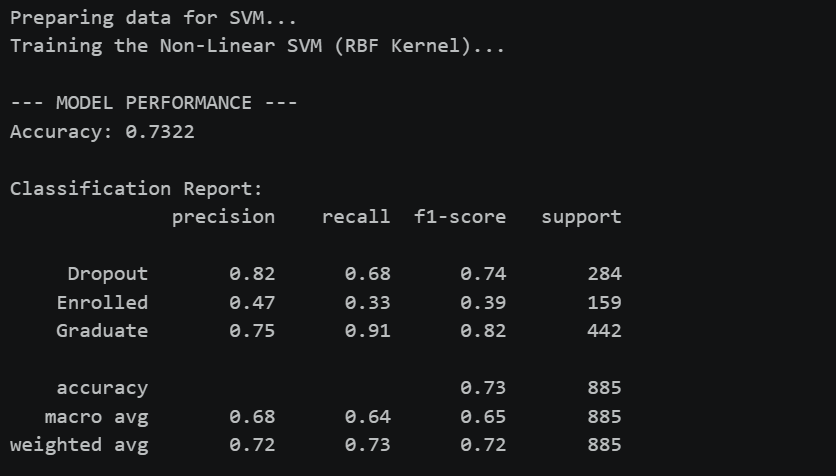

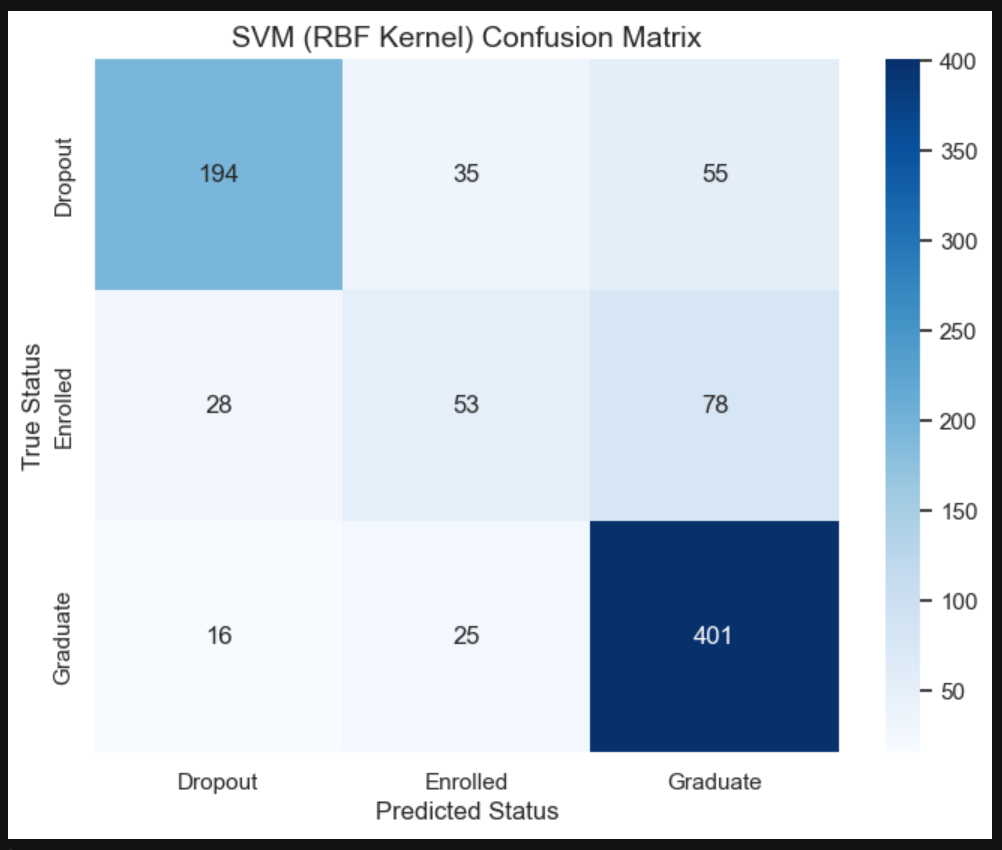

(HAY QUE EJECUTAR EL CÓDIGO CON EL ÚLTIMO NOTEBOOK DE LA PERSONA 2, PARA OBTENER LOS RESULTADOS)

##### SVM Model Interpretation:

1. **Handling Complexity:** By using the RBF kernel and scaling our features, the SVM successfully managed the non-linear relationships between our diverse variables (academic, demographic, and macroeconomic).

2. **Performance:** The model is particularly strong at identifying `Graduate` and `Dropout` students, which are the most definitive states. The `Enrolled` class (students still studying) is inherently harder to predict because they are in a transitional state and share characteristics with both dropouts and graduates.

3. **Value Proposition:** This non-linear approach proves that dropping the redundant variables earlier did not hurt the model's predictive power. Instead, it allowed the SVM to focus on the most impactful features without adding computational noise.